In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import pickle as pkl
from sklearn.model_selection import RandomizedSearchCV, train_test_split

In [21]:
root_path = "./"

In [22]:
combined_features_final_df_train = pd.read_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_train.csv"
)
combined_features_final_df_test = pd.read_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_test.csv"
)

In [23]:
with open('featurization/class_labels.pkl', 'rb') as file:
    class_labels = pkl.load(file)
y_labels = class_labels.rename(columns={"Id": "ID", "Class": "Class"})

combined_features_final_df_train = pd.merge(combined_features_final_df_train, y_labels, on="ID", suffixes=('_byte', '_asm'))
combined_features_final_df_test = pd.merge(combined_features_final_df_test, y_labels, on="ID", suffixes=('_byte', '_asm'))

final_X_train = combined_features_final_df_train.fillna(0).drop(['ID', 'Class'], axis=1)
final_y_train = combined_features_final_df_train["Class"] - 1
final_X_test = combined_features_final_df_test.fillna(0).drop(['ID', 'Class'], axis=1)
final_y_test = combined_features_final_df_test["Class"] - 1

# train val
X_train_final_merged, X_cv_final_merged, y_train_final_merged, y_cv_final_merged = train_test_split(final_X_train, final_y_train, stratify=final_y_train, test_size=0.20, random_state=42)
X_test_final_merged = final_X_test
y_test_final_merged = final_y_test
print('Shape of X_train_final_merged and y_train_final_merged: ', X_train_final_merged.shape, y_train_final_merged.shape)

print('Shape of X_test_final_merged and y_test_final_merged: ', X_test_final_merged.shape, y_test_final_merged.shape)

print('Shape of X_cv_final_merged and y_cv_final_merged ', X_cv_final_merged.shape, y_cv_final_merged.shape)

Shape of X_train_final_merged and y_train_final_merged:  (6955, 2797) (6955,)
Shape of X_test_final_merged and y_test_final_merged:  (2174, 2797) (2174,)
Shape of X_cv_final_merged and y_cv_final_merged  (1739, 2797) (1739,)


In [26]:
# 1. 初始化隨機森林模型
# n_estimators: 樹的數量，建議先用 100 觀察，若運算資源夠可調至 500
# n_jobs=-1: 使用所有 CPU 核心進行平行運算
rf_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, 
                                   n_jobs=-1, 
                                   verbose=1) # verbose=1 可以看到訓練進度

# 2. 訓練模型 (使用你的 Training Set)
print("正在訓練隨機森林模型...")
rf_model.fit(X_train_final_merged, y_train_final_merged)

# 3. 在 Cross-Validation Set 上進行初步驗證
y_cv_pred = rf_model.predict(X_cv_final_merged)
cv_accuracy = accuracy_score(y_cv_final_merged, y_cv_pred)

print(f"\n[CV Set 驗證結果]")
print(f"準確度 (Accuracy): {cv_accuracy:.4f}")

# 4. 在 Test Set 上進行最終評估
y_test_pred = rf_model.predict(X_test_final_merged)
test_accuracy = accuracy_score(y_test_final_merged, y_test_pred)

print(f"\n[Test Set 最終結果]")
print(f"準確度 (Accuracy): {test_accuracy:.4f}")
print("\n詳細分類報告 (Test Set):")
print(classification_report(y_test_final_merged, y_test_pred))

# 5. 查看混淆矩陣 (Optional)
# 這可以幫助你看出哪幾個惡意程式類別最容易被混淆
conf_matrix = confusion_matrix(y_test_final_merged, y_test_pred)
print("\n混淆矩陣 (Confusion Matrix):")
print(conf_matrix)

正在訓練隨機森林模型...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished



[CV Set 驗證結果]
準確度 (Accuracy): 0.9914

[Test Set 最終結果]
準確度 (Accuracy): 0.9899

詳細分類報告 (Test Set):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       308
           1       1.00      1.00      1.00       496
           2       1.00      1.00      1.00       588
           3       0.98      1.00      0.99        95
           4       1.00      0.62      0.77         8
           5       0.98      0.98      0.98       150
           6       1.00      1.00      1.00        80
           7       0.98      0.96      0.97       246
           8       0.99      0.99      0.99       203

    accuracy                           0.99      2174
   macro avg       0.99      0.95      0.96      2174
weighted avg       0.99      0.99      0.99      2174


混淆矩陣 (Confusion Matrix):
[[306   0   0   1   0   0   0   0   1]
 [  1 494   0   0   0   0   0   0   1]
 [  0   0 588   0   0   0   0   0   0]
 [  0   0   0  95   0   0   0   0   0]
 [  0   0   0  

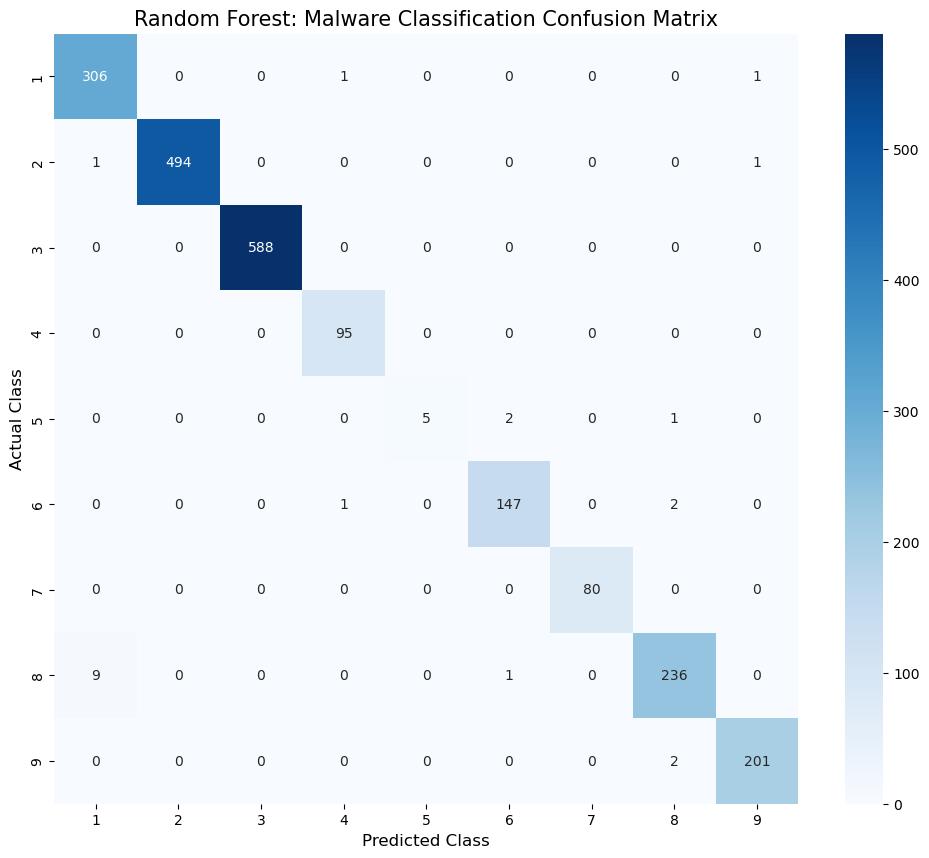

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test_final_merged, y_test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(1, 10), yticklabels=range(1, 10))
plt.title('Random Forest: Malware Classification Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.show()

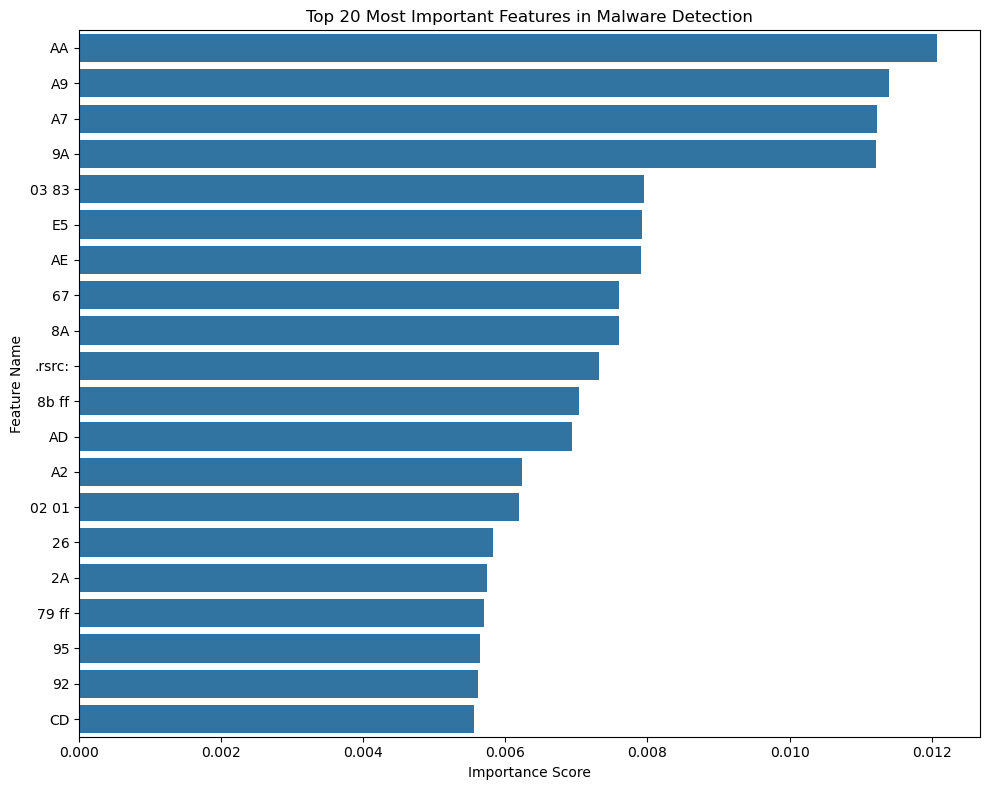

In [31]:
# Extract feature importance
importances = rf_model.feature_importances_
feature_names = final_X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 20 Most Important Features in Malware Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0

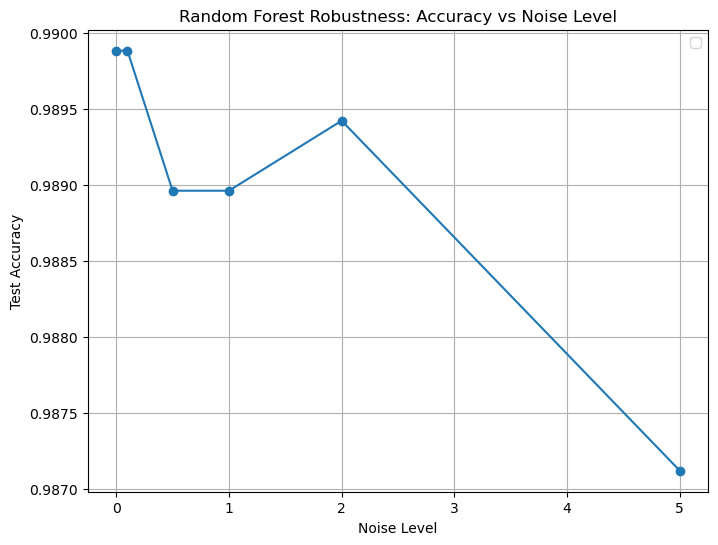

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score

noises = [0, 0.1, 0.5, 1.0, 2.0, 5.0]
rf_accuracies = []

for n in noises:
    # Add Gaussian noise to the scaled test data
    X_test_noisy = X_test_final_merged + np.random.normal(0, n, X_test_final_merged.shape)
    y_pred_n = rf_model.predict(X_test_noisy)
    rf_accuracies.append(accuracy_score(y_test_final_merged, y_pred_n))

plt.figure(figsize=(8, 6))
plt.plot(noises, rf_accuracies, marker='o')
plt.title('Random Forest Robustness: Accuracy vs Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.legend()
plt.show()